In [26]:
import pandas as pd
import numpy as np

history_prefix = "training_history_"

# Combining data

In [27]:
import os
import glob
import re

# Define the path to the mirt-fitting results
results_path = "/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/result/mirt-fitting"

# Get all CSV files starting with the history prefix and containing any k-factor
csv_pattern = os.path.join(results_path, f"{history_prefix}*_k*.csv")
csv_files = glob.glob(csv_pattern)

print(f"Found {len(csv_files)} CSV files with prefix '{history_prefix}' and k-factors")

# List to store individual dataframes
dataframes = []

# Read each CSV file and add scenario column
for csv_file in csv_files:
    # Extract filename without path
    filename = os.path.basename(csv_file)
    
    # Extract k-factor from filename
    k_match = re.search(r'_k(\d+)', filename)
    if not k_match:
        continue  # Skip files without k-factor
    
    k_factor = int(k_match.group(1))
    
    # Extract scenario name: remove prefix and k-factor suffix
    scenario = filename.replace(history_prefix, "").replace(".csv", "")
    scenario = re.sub(r'_k\d+$', '', scenario)  # Remove _k followed by digits
    
    # Read the CSV file
    df = pd.read_csv(csv_file)
    
    # Add scenario and k_factor columns
    df['scenario'] = scenario
    df['k_factor'] = k_factor
    
    # Add to list
    dataframes.append(df)
    
# Combine all dataframes
combined_df = pd.concat(dataframes, ignore_index=True)

print(f"\nCombined DataFrame shape: {combined_df.shape}")
print(f"Unique scenarios: {combined_df['scenario'].nunique()}")
print(f"Available k-factors: {sorted(combined_df['k_factor'].unique())}")
print(f"Scenarios: {sorted(combined_df['scenario'].unique())}")

# Display first few rows
print("\nFirst 5 rows of combined data:")
combined_df.head()

Found 240 CSV files with prefix 'training_history_' and k-factors

Combined DataFrame shape: (45798, 5)
Unique scenarios: 24
Available k-factors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Scenarios: ['air_bench_2024', 'babi_qa', 'bbq', 'boolq', 'civil_comments', 'combined_data', 'commonsense', 'dyck_language_np=3', 'entity_data_imputation', 'entity_matching', 'gsm', 'imdb', 'legal_support', 'legalbench', 'lsat_qa', 'math', 'math_gsm_composite', 'med_qa', 'mmlu', 'raft', 'synthetic_reasoning', 'thai_exam', 'truthful_qa', 'wikifact']

First 5 rows of combined data:


,epoch,train_loss,val_auc,scenario,k_factor
0,1,0.861705,0.504546,air_bench_2024,1
1,2,0.843249,0.511407,air_bench_2024,1
2,3,0.826507,0.518543,air_bench_2024,1
3,4,0.810855,0.525944,air_bench_2024,1
4,5,0.796177,0.533587,air_bench_2024,1


In [28]:
combined_df.groupby('scenario').size()

scenario
air_bench_2024            1070
babi_qa                   1658
bbq                       2815
boolq                     1254
civil_comments             414
combined_data              272
commonsense               2539
dyck_language_np=3        3499
entity_data_imputation    2813
entity_matching           2011
gsm                       1621
imdb                      1473
legal_support             2621
legalbench                1589
lsat_qa                   3889
math                      2301
math_gsm_composite        1395
med_qa                    1675
mmlu                       526
raft                      2461
synthetic_reasoning       1399
thai_exam                 2472
truthful_qa               2870
wikifact                  1161
dtype: int64

In [29]:
# Check what k-factors we have in the raw data
print("K-factors in raw combined_df:")
print(f"Available k-factors: {sorted(combined_df['k_factor'].unique())}")
print(f"Count by k-factor:")
print(combined_df['k_factor'].value_counts().sort_index())
print(f"\nScenarios by k-factor:")
for k in sorted(combined_df['k_factor'].unique()):
    scenarios = combined_df[combined_df['k_factor'] == k]['scenario'].nunique()
    print(f"k={k}: {scenarios} scenarios")

K-factors in raw combined_df:
Available k-factors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Count by k-factor:
k_factor
1     5066
2     5419
3     4991
4     4845
5     4786
6     4507
7     4259
8     3824
9     4063
10    4038
Name: count, dtype: int64

Scenarios by k-factor:
k=1: 24 scenarios
k=2: 24 scenarios
k=3: 24 scenarios
k=4: 24 scenarios
k=5: 24 scenarios
k=6: 24 scenarios
k=7: 24 scenarios
k=8: 24 scenarios
k=9: 24 scenarios
k=10: 24 scenarios


In [30]:
# Group by both scenario and k_factor, then take max values for each combination
combined_df = combined_df.groupby(['scenario', 'k_factor']).max().reset_index()

print(f"After groupby - Shape: {combined_df.shape}")
print(f"Available k-factors: {sorted(combined_df['k_factor'].unique())}")
print(f"Scenarios per k-factor:")
print(combined_df.groupby('k_factor')['scenario'].nunique())

After groupby - Shape: (240, 5)
Available k-factors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Scenarios per k-factor:
k_factor
1     24
2     24
3     24
4     24
5     24
6     24
7     24
8     24
9     24
10    24
Name: scenario, dtype: int64


In [31]:
# Index is already reset in the previous cell
combined_df.head()

,scenario,k_factor,epoch,train_loss,val_auc
0,air_bench_2024,1,130,0.861705,0.909543
1,air_bench_2024,2,120,0.984802,0.915069
2,air_bench_2024,3,124,1.063845,0.915235
3,air_bench_2024,4,144,1.138791,0.911684
4,air_bench_2024,5,99,1.207393,0.910692


In [32]:
# Create DataFrame with the model results
results_data = {
    'scenario': [
        'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact',
        'bbq', 'thai_exam', 'dyck_language_np=3', 'legal_support', 'civil_comments',
        'legalbench', 'raft', 'air_bench_2024', 'math', 'med_qa', 'gsm',
        'boolq', 'mmlu', 'entity_matching', 'entity_data_imputation',
        'commonsense', 'imdb', 'combined_data'
    ],
    'train_auc': [
        0.688523530960083, 0.7754234075546265, 0.8787771463394165, 0.8385953307151794, 0.8949015140533447,
        0.7257800102233887, 0.857973575592041, 0.7987954020500183, 0.7143356800079346, 0.7923104763031006,
        0.8490860462188721, 0.8433337211608887, 0.9189774990081787, 0.9069100618362427, 0.8781333565711975,
        0.9062897562980652, 0.8516445159912109, 0.9107261896133423, 0.9005221128463745, 0.9436786770820618,
        0.9296308755874634, 0.9275050163269043, 0.8401544094085693
    ],
    'test_auc': [
        0.6194833517074585, 0.752168595790863, 0.8685898780822754, 0.825733482837677, 0.8836542367935181,
        0.6776220798492432, 0.8284746408462524, 0.7705100774765015, 0.6697757244110107, 0.774608314037323,
        0.836212158203125, 0.8359396457672119, 0.9038318991661072, 0.8989916443824768, 0.869013786315918,
        0.8985381722450256, 0.833503007888794, 0.8993809223175049, 0.8869590759277344, 0.9344797134399414,
        0.9203937649726868, 0.8829501271247864, 0.8265177607536316
    ],
    'train_cttcorr': [
        0.9999999954797291, 0.9999999890694462, 0.9999999995909886, 0.9999999976074504, 0.9999999986407333,
        0.9999999872610216, 0.9999999915025175, 0.99999999921584, 0.9999999976040401, 0.9999999982895018,
        0.9999999853873718, 0.9999999898960499, 0.9999999965323432, 0.9999999994130362, 0.9999999955530873,
        0.9999999995129949, 0.9999999996984892, 0.999999994816744, 0.9999999996850908, 0.9999999995785793,
        0.9999999981061295, 0.9999999868962981, 0.9999982965698357
    ],
    'test_cttcorr': [
        0.5906119125422994, 0.9706165826374094, 0.9944507503020064, 0.9801349393837014, 0.9955563464912967,
        0.9853548320237024, 0.9473795683343597, 0.9523431791191582, 0.8647175288487944, 0.9993321449878049,
        0.9853292991185817, 0.9667072922095117, 0.9979504514385135, 0.9904288659823243, 0.9823410596225498,
        0.9927657682987716, 0.993096924815468, 0.9973090123780943, 0.996777295569847, 0.96432828871636,
        0.9816468838401071, 0.9922439784181618, 0.9927450093359975
    ]
}

# Create the results DataFrame
results_df = pd.DataFrame(results_data)

In [33]:
resmat = pd.read_pickle('../data/resmat.pkl')

In [34]:
counts_dict = resmat.columns.get_level_values('scenario').value_counts().dropna()
scenario_sizes = {fruit: count for fruit, count in counts_dict.items() if count > 0}
scenario_sizes

{'civil_comments': 29407,
 'mmlu': 13223,
 'wikifact': 5511,
 'air_bench_2024': 4985,
 'imdb': 3530,
 'babi_qa': 3461,
 'boolq': 3316,
 'synthetic_reasoning': 2234,
 'legalbench': 1997,
 'truthful_qa': 1888,
 'entity_matching': 1396,
 'raft': 1336,
 'bbq': 999,
 'med_qa': 998,
 'gsm': 997,
 'legal_support': 594,
 'thai_exam': 557,
 'dyck_language_np=3': 500,
 'commonsense': 498,
 'lsat_qa': 454,
 'math': 436,
 'entity_data_imputation': 395}

In [35]:


# Create a DataFrame with scenario sizes
size_df = pd.DataFrame(list(scenario_sizes.items()), columns=['scenario', 'size'])
print("Scenario sizes:")
print(size_df.sort_values('size', ascending=False))

Scenario sizes:
                  scenario   size
0           civil_comments  29407
1                     mmlu  13223
2                 wikifact   5511
3           air_bench_2024   4985
4                     imdb   3530
5                  babi_qa   3461
6                    boolq   3316
7      synthetic_reasoning   2234
8               legalbench   1997
9              truthful_qa   1888
10         entity_matching   1396
11                    raft   1336
12                     bbq    999
13                  med_qa    998
14                     gsm    997
15           legal_support    594
16               thai_exam    557
17      dyck_language_np=3    500
18             commonsense    498
19                 lsat_qa    454
20                    math    436
21  entity_data_imputation    395


In [36]:
# Merge the results DataFrame with the combined training history DataFrame
merged_df = combined_df.merge(results_df, on='scenario', how='left')

# Also merge with size information
merged_df = merged_df.merge(size_df, on='scenario', how='left')

print(f"Merged DataFrame shape: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}")

# Check for any scenarios that didn't match
scenarios_in_combined = set(combined_df['scenario'].unique())
scenarios_in_results = set(results_df['scenario'].unique())
scenarios_in_sizes = set(size_df['scenario'].unique())

print(f"\nScenarios in combined_df: {len(scenarios_in_combined)}")
print(f"Scenarios in results_df: {len(scenarios_in_results)}")
print(f"Scenarios in size_df: {len(scenarios_in_sizes)}")
print(f"Scenarios in all: {len(scenarios_in_combined.intersection(scenarios_in_results).intersection(scenarios_in_sizes))}")

if scenarios_in_combined - scenarios_in_results:
    print(f"Scenarios in combined_df but not in results_df: {scenarios_in_combined - scenarios_in_results}")
if scenarios_in_results - scenarios_in_combined:
    print(f"Scenarios in results_df but not in combined_df: {scenarios_in_results - scenarios_in_combined}")
if scenarios_in_combined - scenarios_in_sizes:
    print(f"Scenarios in combined_df but not in size_df: {scenarios_in_combined - scenarios_in_sizes}")

Merged DataFrame shape: (240, 10)
Columns: ['scenario', 'k_factor', 'epoch', 'train_loss', 'val_auc', 'train_auc', 'test_auc', 'train_cttcorr', 'test_cttcorr', 'size']

Scenarios in combined_df: 24
Scenarios in results_df: 23
Scenarios in size_df: 22
Scenarios in all: 22
Scenarios in combined_df but not in results_df: {'math_gsm_composite'}
Scenarios in combined_df but not in size_df: {'math_gsm_composite', 'combined_data'}


In [37]:
# Prepare data for plotting - include k_factor information
df = merged_df[['val_auc', 'test_auc', 'scenario', 'k_factor', 'size']].sort_values(by='test_auc', ascending=True).dropna().copy()
df.rename(columns={'val_auc': 'mirt', 'test_auc': 'irt'}, inplace=True)

# Show unique k-factors available
print(f"Available k-factors: {sorted(df['k_factor'].unique())}")
print(f"Data shape: {df.shape}")
df.head()

Available k-factors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Data shape: (220, 5)


,mirt,irt,scenario,k_factor,size
144,0.844361,0.619483,lsat_qa,5,454.0
145,0.830923,0.619483,lsat_qa,6,454.0
146,0.828669,0.619483,lsat_qa,7,454.0
147,0.824287,0.619483,lsat_qa,8,454.0
143,0.839630,0.619483,lsat_qa,4,454.0


In [38]:
df.to_pickle('../data/calibration_results.pkl')

# Model fit assessment

In [2]:
import pandas as pd

df = pd.read_pickle('../data/calibration_results.pkl')

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_8837/207101899.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


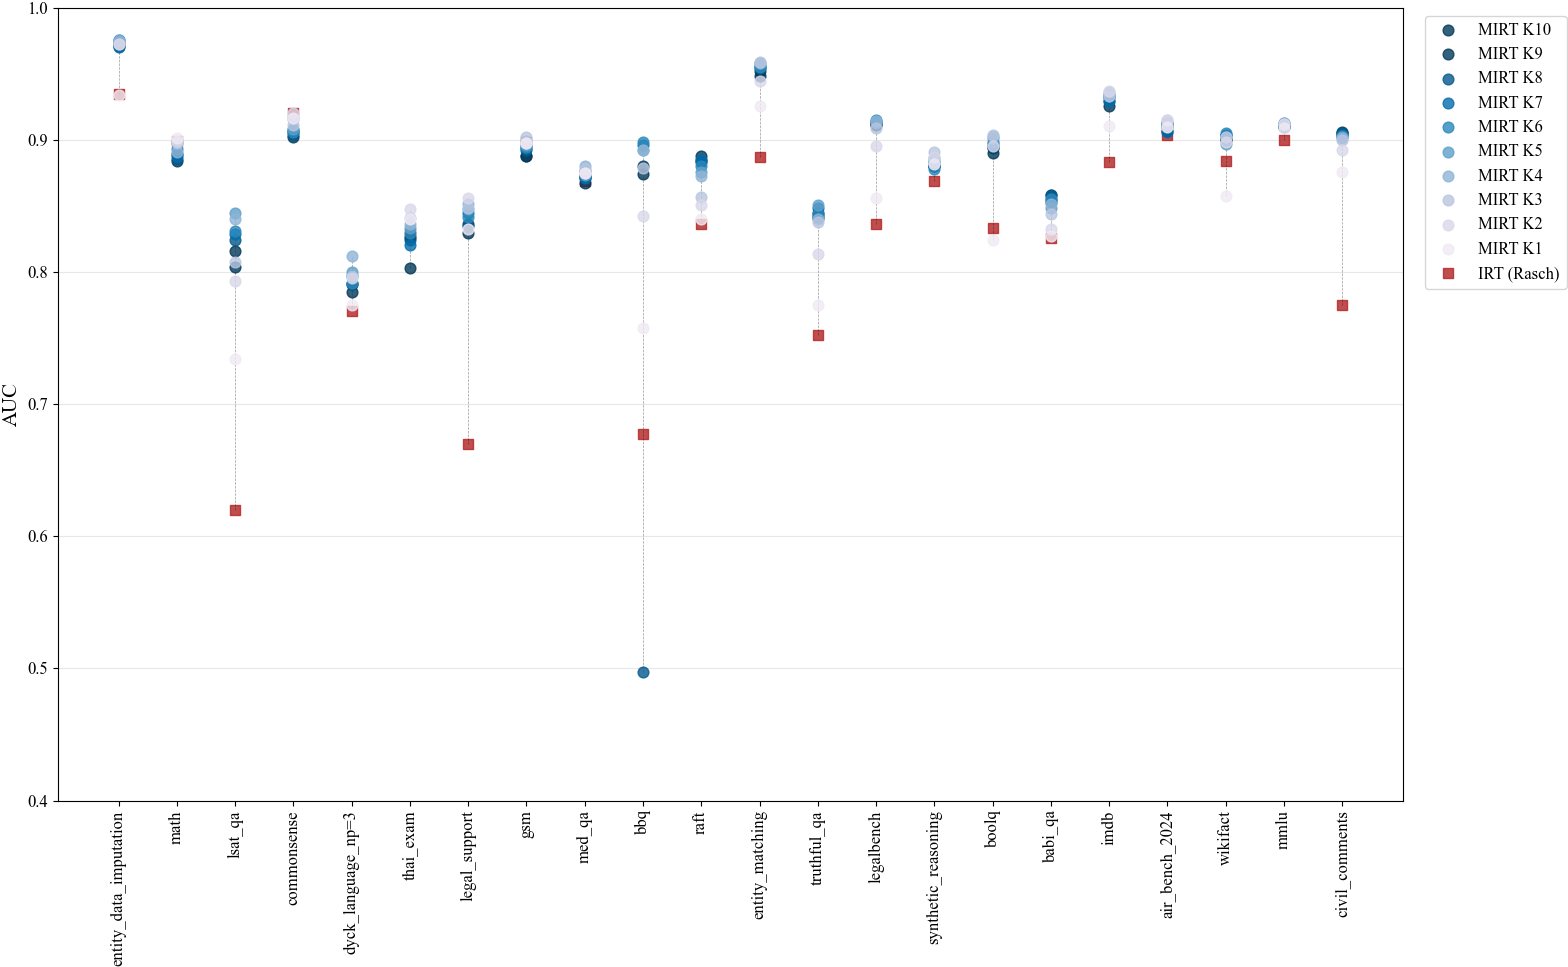

In [3]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..') 
import style

# Create the transposed dumbbell plot with k-factor colors, sorted by scenario size
fig, ax = plt.subplots(figsize=(16, 10))

# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df['scenario'].unique(), key=lambda x: scenario_size_mapping[x])
k_factors = sorted(df['k_factor'].unique())

# Create a grayscale colormap that reflects numerical order
colors = plt.get_cmap('PuBu')
# Use a subset of the colormap to avoid too light colors
color_map = {k: colors(0.1 + 1 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Create x positions for each scenario (now ordered by size)
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# Plot for each k-factor
for k_factor in reversed(k_factors):
	df_k = df[df['k_factor'] == k_factor]
	
	if len(df_k) == 0:
		continue
	
	# Get x positions for this k-factor's scenarios
	x_positions = [x_pos[scenario] for scenario in df_k['scenario']]
	
	# Plot the MIRT points
	ax.scatter(x_positions, df_k['mirt'], 
			  color=color_map[k_factor], s=60, 
			  label=f'MIRT K{k_factor}', 
			  marker='o', alpha=0.8, zorder=3)

# Plot IRT (Rasch) points - same for all k-factors
# Get one representative IRT value per scenario (they should be the same across k-factors)
df_irt = df.groupby('scenario')[['irt', 'size']].first().reset_index()
df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT (Rasch)', 
          marker='s', alpha=0.8, zorder=2)

# Plot connecting lines between lowest and highest values for each scenario
for scenario in scenarios:
	df_scenario = df[df['scenario'] == scenario]
	if len(df_scenario) == 0:
		continue
	
	x = x_pos[scenario]
	
	# Get all values (both IRT and MIRT) for this scenario
	all_values = list(df_scenario['mirt']) + [df_scenario['irt'].iloc[0]]
	
	# Find min and max values
	min_val = min(all_values)
	max_val = max(all_values)
	
	# Draw line from lowest to highest value
	ax.plot([x, x], [min_val, max_val], 'k--', linewidth=0.5, alpha=0.4)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
# Create labels with both scenario name and size
scenario_labels = [f"{scenario}" for scenario in scenarios]
ax.set_xticklabels(scenario_labels, rotation=90)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_8837/1056642770.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


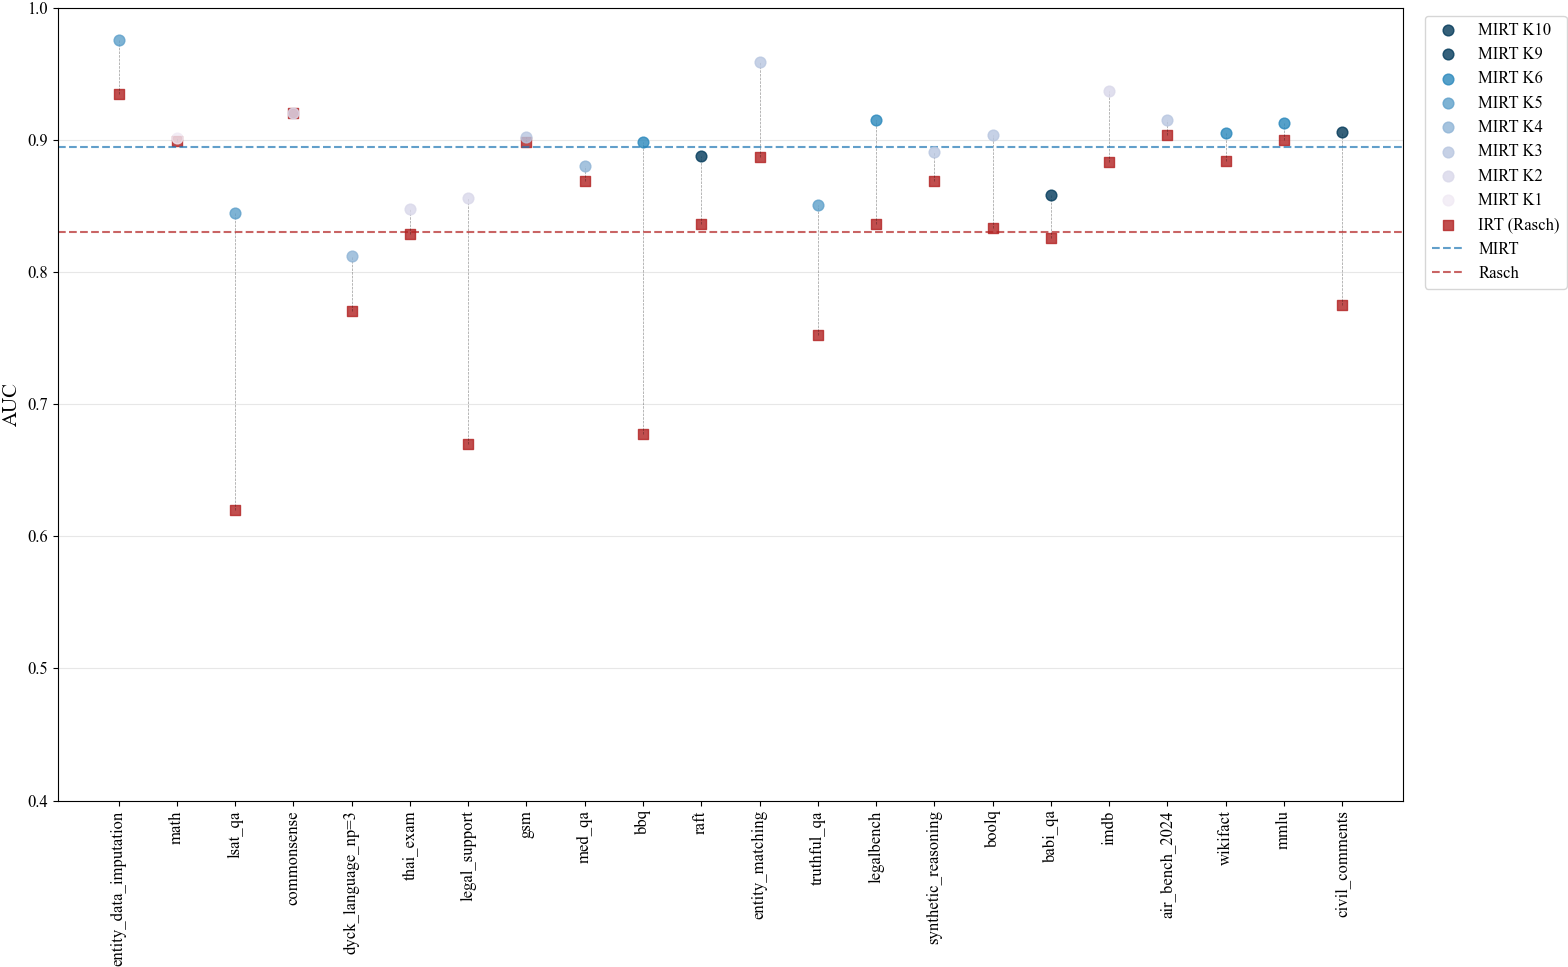

In [4]:
# Create simplified plot showing only IRT and highest MIRT AUC, sorted by scenario size
fig, ax = plt.subplots(figsize=(16, 10))
# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df['scenario'].unique(), key=lambda x: scenario_size_mapping[x])
k_factors = sorted(df['k_factor'].unique())

# Create x positions for each scenario (now ordered by size)
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# For each scenario, find the highest MIRT AUC across all k-factors
highest_mirt_data = []
for scenario in scenarios:
    df_scenario = df[df['scenario'] == scenario]
    if len(df_scenario) > 0:
        # Find the row with the highest MIRT AUC for this scenario
        max_mirt_row = df_scenario.loc[df_scenario['mirt'].idxmax()]
        highest_mirt_data.append({
            'scenario': scenario,
            'mirt': max_mirt_row['mirt'],
            'k_factor': max_mirt_row['k_factor'],
            'irt': max_mirt_row['irt'],
            'size': max_mirt_row['size']
        })

# Convert to DataFrame for easier handling
highest_mirt_df = pd.DataFrame(highest_mirt_data)

# Create the same color map as before
colors = plt.get_cmap('PuBu')
color_map = {k: colors(0.1 + 1 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Get unique k-factors that actually appear as highest performers
highest_k_factors = sorted(highest_mirt_df['k_factor'].unique())

# Plot the highest MIRT points grouped by k-factor for legend purposes
plotted_k_factors = set()
for k_factor in reversed(highest_k_factors):
    # Get all scenarios where this k-factor is the highest performer
    k_data = highest_mirt_df[highest_mirt_df['k_factor'] == k_factor]
    
    x_positions = [x_pos[scenario] for scenario in k_data['scenario']]
    
    # Plot points for this k-factor
    ax.scatter(x_positions, k_data['mirt'], 
              color=color_map[k_factor], s=60, 
              label=f'MIRT K{k_factor}', 
              marker='o', alpha=0.8, zorder=3)
    
    plotted_k_factors.add(k_factor)

# Plot IRT (Rasch) points - same as before
df_irt = df.groupby('scenario')[['irt', 'size']].first().reset_index()
df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT (Rasch)', 
          marker='s', alpha=0.8, zorder=2)

# Plot connecting lines between IRT and highest MIRT for each scenario
for _, row in highest_mirt_df.iterrows():
    x = x_pos[row['scenario']]
    
    # Draw line between IRT and highest MIRT value
    ax.plot([x, x], [row['irt'], row['mirt']], 'k--', linewidth=0.5, alpha=0.4)

# Calculate and plot average lines
mirt_avg = highest_mirt_df['mirt'].mean()
irt_avg = df_irt['irt'].mean()

# Add horizontal lines for averages
ax.axhline(y=mirt_avg, color='C0', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'MIRT', zorder=2)
ax.axhline(y=irt_avg, color='firebrick', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'Rasch', zorder=2)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
# Create labels with both scenario name and size
scenario_labels = [f"{scenario}" for scenario in scenarios]
ax.set_xticklabels(scenario_labels, rotation=90)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_8837/799792649.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


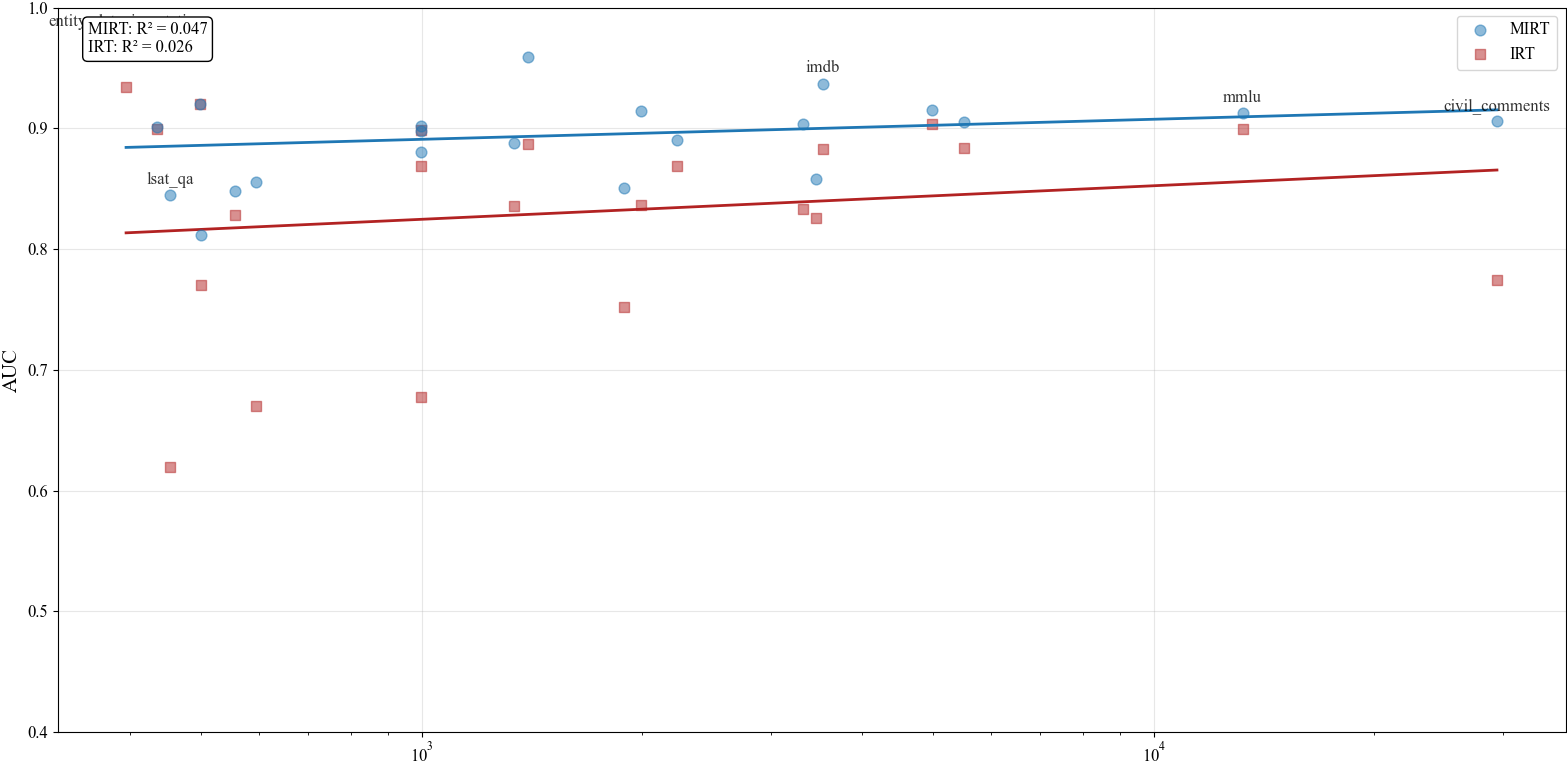

In [5]:
# Create scatter plot: Dataset Size vs AUC Performance
import numpy as np
from scipy import stats

fig, ax = plt.subplots(figsize=(16, 8))

# Prepare data for the size vs AUC plot
# Get highest MIRT performance for each scenario
size_auc_data = []
for scenario in df['scenario'].unique():
    df_scenario = df[df['scenario'] == scenario]
    if len(df_scenario) > 0:
        # Get the highest MIRT AUC for this scenario
        max_mirt_row = df_scenario.loc[df_scenario['mirt'].idxmax()]
        
        size_auc_data.append({
            'scenario': scenario,
            'size': max_mirt_row['size'],
            'mirt_highest': max_mirt_row['mirt'],
            'irt': max_mirt_row['irt']
        })

# Convert to DataFrame
size_auc_df = pd.DataFrame(size_auc_data)

# Sort by size for cleaner plotting
size_auc_df = size_auc_df.sort_values('size')

# Plot scatter points
ax.scatter(size_auc_df['size'], size_auc_df['mirt_highest'], 
          color='C0', s=60, alpha=0.5, label='MIRT', zorder=3)
ax.scatter(size_auc_df['size'], size_auc_df['irt'], marker='s',
          color='firebrick', s=60, alpha=0.5, label='IRT', zorder=2)

# Fit and plot trend lines
# MIRT trend line
mirt_slope, mirt_intercept, mirt_r, _, _ = stats.linregress(np.log10(size_auc_df['size']), size_auc_df['mirt_highest'])
x_trend = np.logspace(np.log10(size_auc_df['size'].min()), np.log10(size_auc_df['size'].max()), 100)
mirt_trend = mirt_slope * np.log10(x_trend) + mirt_intercept
ax.plot(x_trend, mirt_trend, color='C0', linestyle='-', linewidth=2, alpha=1, zorder=2)

# IRT trend line
irt_slope, irt_intercept, irt_r, _, _ = stats.linregress(np.log10(size_auc_df['size']), size_auc_df['irt'])
irt_trend = irt_slope * np.log10(x_trend) + irt_intercept
ax.plot(x_trend, irt_trend, color='firebrick', linestyle='-', linewidth=2, alpha=1, zorder=2)

# Add scenario labels for key points
for _, row in size_auc_df.iterrows():
	# Label only some scenarios to avoid clutter
	if row['scenario'] in ['civil_comments', 'entity_data_imputation', 'lsat_qa', 'mmlu', 'imdb']:
		ax.annotate(row['scenario'], 
				   (row['size'], row['mirt_highest']), 
				   xytext=(0, 8), textcoords='offset points', 
				   fontsize=12, alpha=0.8, ha='center')

# Customize the plot
ax.set_xscale('log')
ax.set_ylabel('AUC')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.0)

# Add correlation info
ax.text(0.02, 0.98, f'MIRT: R² = {mirt_r**2:.3f}\nIRT: R² = {irt_r**2:.3f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=1))

plt.tight_layout()
plt.show()

# Interpretability check
`legalbench` with k=2

In [6]:
from load_params import load_and_rotate
import pandas as pd
import sys
sys.path.append('..') 
import style
# Concatenate math and gsm outputs for theta, a, b
theta, a, b = load_and_rotate('../result/mirt-fitting/mirt_model_k2_legalbench.pt', rotation=None)

resmat = pd.read_pickle('../data/resmat.pkl')

conv = ['legalbench']

conv_mask = resmat.loc[:, resmat.columns.get_level_values("scenario").isin(conv)]

conv_questions = conv_mask.columns.get_level_values('input.text').tolist()


theta_df = pd.DataFrame(theta, columns=[f'Factor_{i+1}' for i in range(theta.shape[1])], index=resmat.index)
a_df = pd.DataFrame(a, columns=[f'Factor_{i+1}' for i in range(a.shape[1])])
a_df['question'] = conv_questions

models_answered = conv_mask.dropna(how='all').index.tolist()
accuracy = (conv_mask.sum(axis=1) / conv_mask.notnull().sum(axis=1)).loc[models_answered]
theta_irt = pd.read_csv('../result/irt-fitting/calibration_result_theta_legalbench.csv')
theta_df = theta_df.loc[models_answered]
theta_df['accuracy'] = accuracy
theta_df['irt'] = theta_irt.values

from calculate_p import compute_eap_map_sd

# Example shapes
Y = conv_mask.dropna(how='all').values
A = a_df.select_dtypes(include=[np.number]).values

eap, map_, sd = compute_eap_map_sd(Y, A, b, n_points=21)

--- Loading from Cache ---
Loaded cached theta shape: (183, 2)
Loaded cached a shape: (1997, 2)
Loaded cached b shape: (1997,)



In [10]:
import numpy as np
from factor_analyzer.rotator import Rotator

rotator = Rotator(method="oblimin")
A_rot = rotator.fit_transform(A)

# Rotation matrix R can be retrieved
R = rotator.rotation_

# Apply the same rotation to person scores
eap_rot = eap @ R
map_rot = map_ @ R

a_df['Factor_1'] = A_rot[:,0]
a_df['Factor_2'] = A_rot[:,1]
a_df.to_csv('conv_item_loadings_rotated.csv', index=False)
a_df.sort_values(by='Factor_1', ascending=False).copy().head(250).to_csv('conv_item_loadings_rotated_sorted_f1.csv', index=False)
a_df.sort_values(by='Factor_1', ascending=True).copy().head(250).to_csv('conv_item_loadings_rotated_sorted_f1_asc.csv', index=False)
a_df.sort_values(by='Factor_2', ascending=False).copy().head(250).to_csv('conv_item_loadings_rotated_sorted_f2.csv', index=False)
a_df.sort_values(by='Factor_2', ascending=True).copy().head(250).to_csv('conv_item_loadings_rotated_sorted_f2_asc.csv', index=False)

theta_score_df = pd.DataFrame(eap_rot, columns=[f'f{i+1}' for i in range(eap_rot.shape[1])], index=theta_df.index)
theta_score_df['accuracy'] = accuracy
theta_score_df['irt'] = theta_irt.values
theta_score_df.dropna(how='all', inplace=True)
theta_score_df = theta_score_df.round(6)


/Users/ronan/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ronan/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


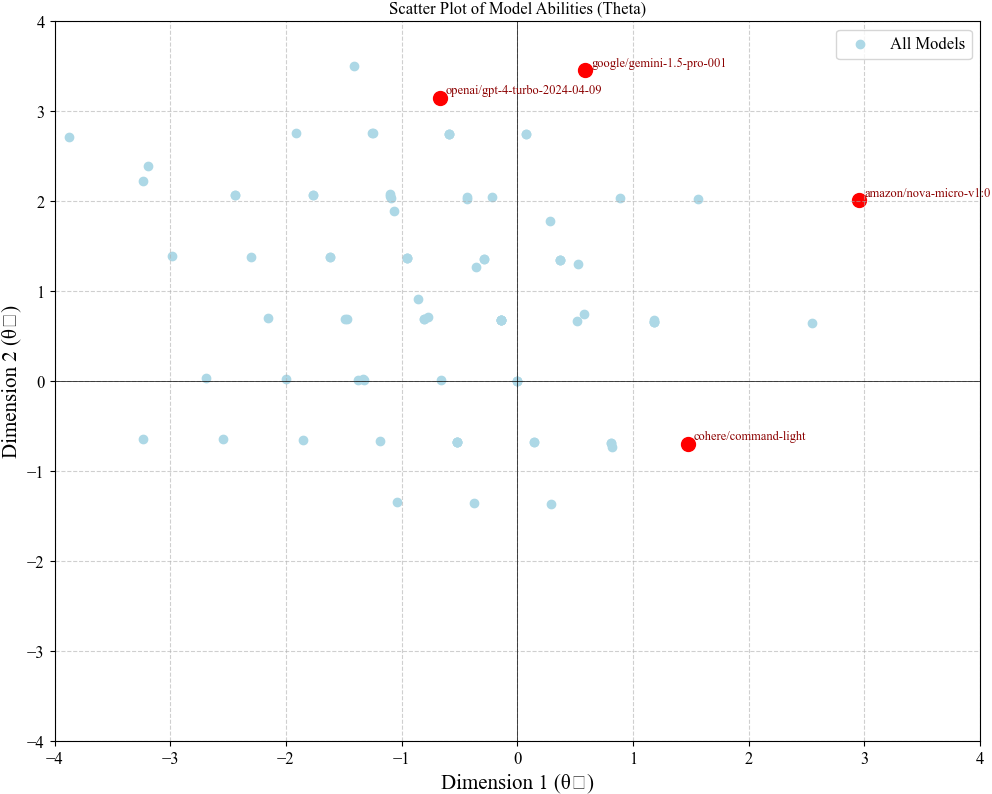

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Create a Sample theta_df DataFrame ---
# (Replace this with your actual theta_df)
# We'll create a sample with more points than just the ones to be labeled.
np.random.seed(42)
model_names = [
    'google/gemini-1.5-pro-001', 'openai/gpt-4-turbo-2024-04-09',
    'amazon/nova-micro-v1:0', 'cohere/command-light',
    'anthropic/claude-3-opus-20240229', 'mistralai/mistral-large-latest',
    'meta-llama/llama-3-70b-instruct'
]

# --- 2. Define the labels you want to plot ---
labels_to_plot = [
    'google/gemini-1.5-pro-001',
    'openai/gpt-4-turbo-2024-04-09',
    'amazon/nova-micro-v1:0',
    'cohere/command-light'
]

# --- 3. Create the plot ---
plt.figure(figsize=(10, 8))

# Plot all points from the DataFrame as a background
plt.scatter(theta_score_df['f1'], theta_score_df['f2'], c='lightblue', label='All Models')

# Highlight and label the specific points
for label in labels_to_plot:
    if label in theta_score_df.index:
        # Get the coordinates for the label
        x = theta_score_df.loc[label, 'f1']
        y = theta_score_df.loc[label, 'f2']
        
        # Plot a more prominent marker for the specific model
        plt.scatter(x, y, c='red', s=100) # s is marker size
        
        # Add the text label slightly offset from the point
        plt.text(x + 0.05, y + 0.05, label, fontsize=9, color='darkred')

# --- 4. Formatting ---
plt.title('Scatter Plot of Model Abilities (Theta)')
plt.xlabel('Dimension 1 (θ₁)')
plt.ylabel('Dimension 2 (θ₂)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend()
plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_8837/1066400302.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


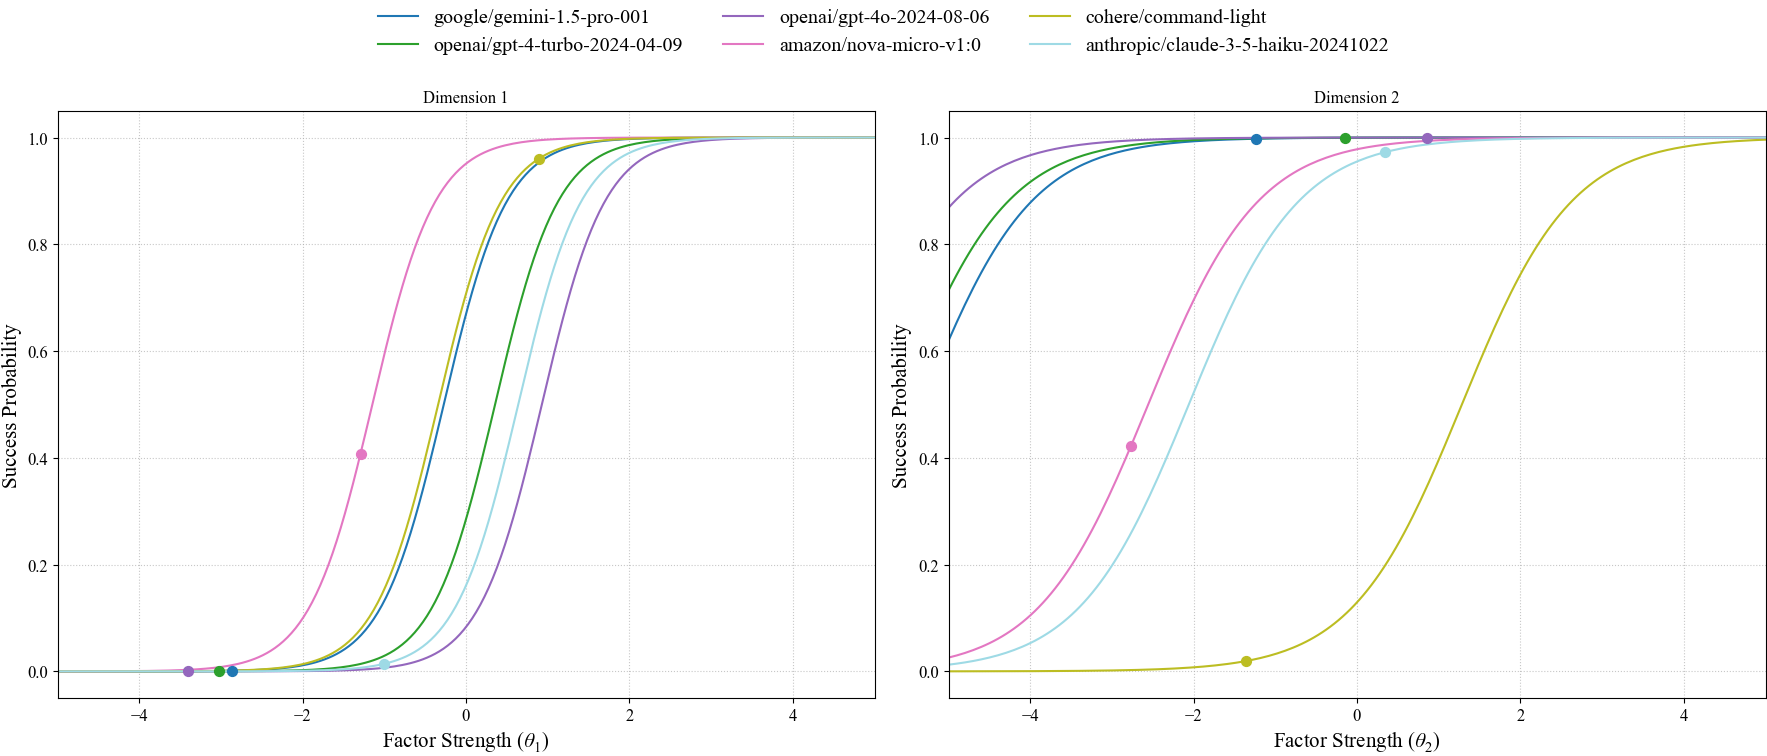

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

def plot_conditional_iccs_for_models(theta_df, a_df, b_df, labels_to_plot):
    """
    Plots Conditional Item Characteristic Curves for a list of models.
    Each model gets its own curve on an ability (theta) x-axis.
    """
    # 1. Find the most representative item for each dimension
    dim1_item_idx = (a_df.iloc[:, 0] - a_df.iloc[:, 1]).idxmax()
    dim2_item_idx = (a_df.iloc[:, 1] - a_df.iloc[:, 0]).idxmax()

    a1_params = a_df.loc[dim1_item_idx]
    b1_param = b_df.loc[dim1_item_idx, 'Difficulty']
    
    a2_params = a_df.loc[dim2_item_idx]
    b2_param = b_df.loc[dim2_item_idx, 'Difficulty']

    # 2. Set up the figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Use a color cycle for the models
    colors = plt.cm.tab20(np.linspace(0, 1, len(labels_to_plot)))
    ax1.set_prop_cycle(cycler('color', colors))
    ax2.set_prop_cycle(cycler('color', colors))

    # --- Plot for Dimension 1 ---
    theta1_range = np.linspace(-5, 5, 200) 
    for label in labels_to_plot:
        if label in theta_df.index:
            theta_model = theta_df.loc[label]
            theta2_fixed = theta_model.iloc[1]

            prob_curve = 1 / (1 + np.exp(-(a1_params.values[0] * theta1_range + a1_params.values[1] * theta2_fixed - b1_param)))
            ax1.plot(theta1_range, prob_curve, label=label)

            actual_prob = 1 / (1 + np.exp(-(np.dot(a1_params.values, theta_model.values) - b1_param)))
            ax1.scatter(theta_model.iloc[0], actual_prob, s=50, zorder=5, color=ax1.get_lines()[-1].get_color())

    ax1.set_title('Dimension 1')
    ax1.set_xlabel(r'Factor Strength ($\theta_1$)')
    ax1.set_ylabel('Success Probability')
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_xlim(-5, 5)
    ax1.grid(True, linestyle=':', alpha=0.7)

    # --- Plot for Dimension 2 ---
    theta2_range = np.linspace(-5, 5, 200)
    for label in labels_to_plot:
        if label in theta_df.index:
            theta_model = theta_df.loc[label]
            theta1_fixed = theta_model.iloc[0]

            prob_curve = 1 / (1 + np.exp(-(a2_params.values[0] * theta1_fixed + a2_params.values[1] * theta2_range - b2_param)))
            ax2.plot(theta2_range, prob_curve, label=label)

            actual_prob = 1 / (1 + np.exp(-(np.dot(a2_params.values, theta_model.values) - b2_param)))
            ax2.scatter(theta_model.iloc[1], actual_prob, s=50, zorder=5, color=ax2.get_lines()[-1].get_color())
            
    ax2.set_title('Dimension 2')
    ax2.set_xlabel(r'Factor Strength ($\theta_2$)')
    ax2.set_ylabel('Success Probability')
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_xlim(-5, 5)
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    # --- Legend and Layout Adjustment (Updated based on your reference) ---
    handles, labels = ax1.get_legend_handles_labels()

    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize='large', frameon=False)

    # REPLACED: Use tight_layout() to automatically adjust the subplot positions to make room for the legend.
    plt.tight_layout()

    plt.show()
# --- Your Calling Code ---

labels_to_plot = [
    'google/gemini-1.5-pro-001', 'openai/gpt-4-turbo-2024-04-09', 'openai/gpt-4o-2024-08-06',
    'amazon/nova-micro-v1:0', 'cohere/command-light', 'anthropic/claude-3-5-haiku-20241022',
]

# Ensure your real DataFrames are 2D and have matching indices
a_df_2d = a_df.iloc[:, :2]
theta_df_2d = theta_df.iloc[:, :2]
a_df_2d.index = conv_questions
b_df = pd.DataFrame(b, columns=['Difficulty'], index=conv_questions)

# Call the function with your actual MIRT results
plot_conditional_iccs_for_models(theta_df_2d, a_df_2d, b_df, labels_to_plot)

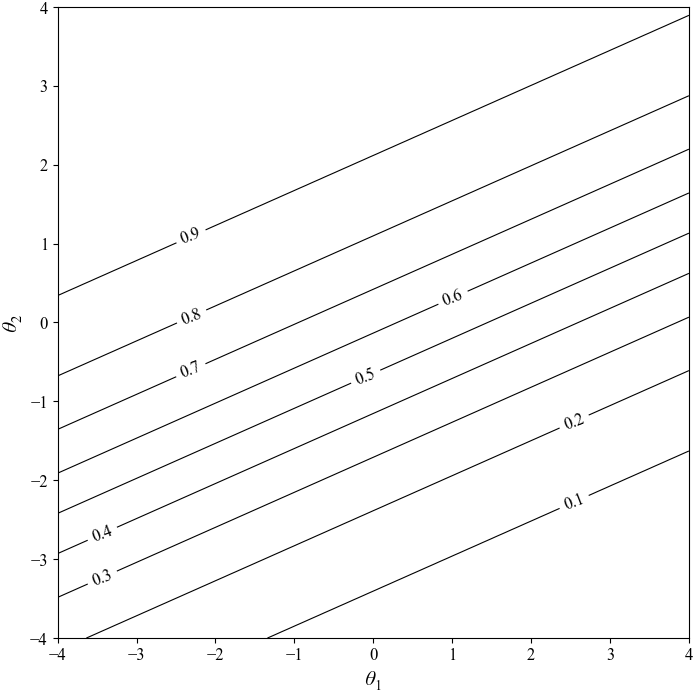

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_item_contour(item_name, a_df, b_df):
    """
    Generates a 2D Item Characteristic Contour plot in black and white for a single item.
    """
    if item_name not in a_df.index or item_name not in b_df.index:
        print(f"Error: Item '{item_name}' not found in a_df or b_df.")
        return

    # 1. Get parameters for the selected item
    a_params = a_df.loc[item_name].values
    b_param = b_df.loc[item_name, 'Difficulty']

    # 2. Create a grid of theta (ability) values
    theta_range = np.linspace(-4, 4, 100)
    theta1_grid, theta2_grid = np.meshgrid(theta_range, theta_range)

    # 3. Calculate the probability of a correct response across the grid
    prob_surface = 1 / (1 + np.exp(-(a_params[0] * theta1_grid + a_params[1] * theta2_grid - b_param)))

    # 4. Create the 2D contour plot
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # CHANGED: Contour lines are now black to be visible on a white background
    contour_lines = ax.contour(theta1_grid, theta2_grid, prob_surface, levels=np.arange(0.1, 1.0, 0.1), colors='black', linewidths=0.8)
    ax.clabel(contour_lines, inline=True, fontsize=12, fmt='%1.1f')

    # 5. Formatting
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    # ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_aspect('equal')
    
    plt.show()

# Choose an item to plot from your a_df's index
item_to_plot = a_df_2d.index[4] 

# Call the function
plot_item_contour(item_to_plot, a_df_2d, b_df)

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_8837/3964282607.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


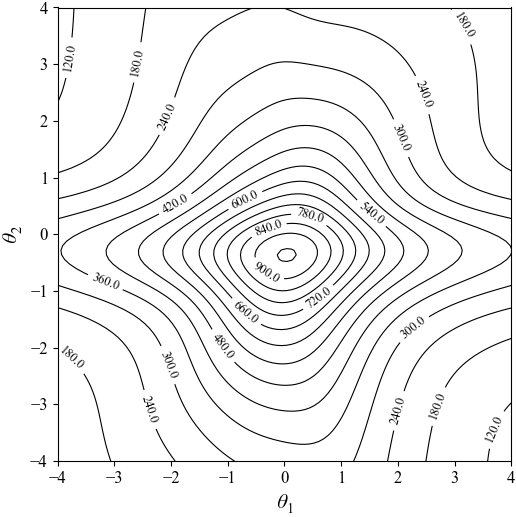

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_test_information(ax, a_df, b_df):
    """
    Calculates and plots the Test Information Contour Map on a given axis (no rotation).

    Args:
        ax (matplotlib.axes.Axes): The subplot axis to draw on.
        a_df (pd.DataFrame): DataFrame of item discriminations.
        b_df (pd.DataFrame): DataFrame of item difficulties.
    """
    # 1. Create a grid of theta values
    theta_range = np.linspace(-4, 4, 100)
    theta1_grid, theta2_grid = np.meshgrid(theta_range, theta_range)
    total_information_surface = np.zeros_like(theta1_grid)

    # 2. Calculate total information using original parameters
    for i in range(len(a_df)):
        a_params = a_df.iloc[i].values
        b_param = b_df.iloc[i]['Difficulty']

        prob_surface = 1 / (1 + np.exp(-(a_params[0] * theta1_grid + a_params[1] * theta2_grid - b_param)))
        item_info_surface = np.sum(np.square(a_params)) * prob_surface * (1 - prob_surface)
        total_information_surface += item_info_surface

    # 3. Plot the contour on the provided axis
    contour_lines = ax.contour(theta1_grid, theta2_grid, total_information_surface, levels=15, colors='black', linewidths=0.8)
    ax.clabel(contour_lines, inline=True, fontsize=9, fmt='%1.1f')
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_aspect('equal')

# Set up the figure with a single subplot
fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))

# Plot for 0 degrees (no rotation)
plot_test_information(ax, a_df_2d, b_df)

plt.tight_layout()
plt.show()

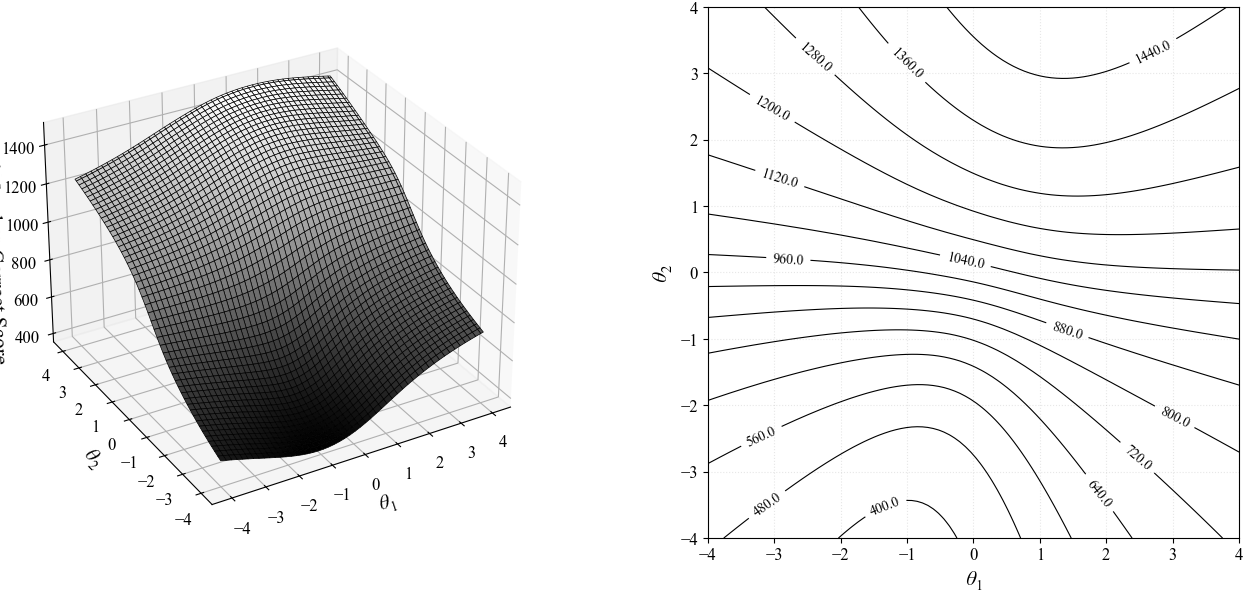

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_test_characteristic_pair(a_df, b_df):
    """
    Calculates and plots the Test Characteristic Surface and its corresponding
    2D contour map.

    Args:
        a_df (pd.DataFrame): DataFrame of item discriminations for the entire test.
        b_df (pd.DataFrame): DataFrame of item difficulties for the entire test.
    """
    # 1. Create a grid of theta (ability) values
    theta_range = np.linspace(-4, 4, 100)
    theta1_grid, theta2_grid = np.meshgrid(theta_range, theta_range)

    # 2. Calculate the Expected Number-Correct Score across the grid
    # This is the sum of probabilities for all items.
    expected_score_surface = np.zeros_like(theta1_grid)

    for i in range(len(a_df)):
        a_params = a_df.iloc[i].values
        b_param = b_df.iloc[i]['Difficulty']
        
        # Calculate probability for this item and add it to the total expected score
        prob_surface = 1 / (1 + np.exp(-(a_params[0] * theta1_grid + a_params[1] * theta2_grid - b_param)))
        expected_score_surface += prob_surface

    # 3. Set up the figure with two subplots
    fig = plt.figure(figsize=(14, 6))

    # --- Subplot 1: 3D Surface ---
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    
    ax1.plot_surface(theta1_grid, theta2_grid, expected_score_surface,
                     cmap='gray', linewidth=0.5, edgecolor='black')
    
    ax1.set_xlabel(r'$\theta_1$')
    ax1.set_ylabel(r'$\theta_2$')
    ax1.set_zlabel('Expected Number-Correct Score')
    ax1.view_init(elev=30, azim=-120)

    # --- Subplot 2: 2D Contour Plot ---
    ax2 = fig.add_subplot(1, 2, 2)

    contour_lines = ax2.contour(theta1_grid, theta2_grid, expected_score_surface, levels=15, colors='black', linewidths=0.8)
    ax2.clabel(contour_lines, inline=True, fontsize=10, fmt='%1.1f')

    ax2.set_xlabel(r'$\theta_1$')
    ax2.set_ylabel(r'$\theta_2$')
    ax2.grid(True, linestyle=':', alpha=0.3)
    ax2.set_aspect('equal')
    plt.show()

# Call the function
plot_test_characteristic_pair(a_df_2d, b_df)

# Validity

In [110]:
import pandas as pd

model_spec = pd.read_csv('../data/model_specs.csv')

In [111]:
model_spec.dropna(subset=['size'], inplace=True)
model_spec.sort_values(by='size', ascending=False, inplace=True)
model_spec

,code,name,size,pretrain,flops
42,microsoft/TNLGv2_530B,TNLG v2 (530B),530.00,0.27,143.1
115,snowflake/snowflake-arctic-instruct,Arctic Instruct,480.00,0.40,768.0
163,meta/llama-3.1-405b-instruct-turbo,Llama 3.1 Instruct Turbo (405B),405.00,15.00,36450.0
50,ai21/j1-jumbo,J1-Jumbo v1 (178B),178.00,0.30,53.4
52,ai21/j2-jumbo,Jurassic-2 Jumbo (178B),178.00,1.20,213.6
...,...,...,...,...,...
63,openai/babbage,babbage (1.3B),1.30,NaN,NaN
89,openai/text-ada-001,text-ada-001,1.20,NaN,NaN
2,eleutherai/pythia-1b-v0,Pythia (1B),1.00,0.30,1.8
71,cohere/small-20220720,Cohere small v20220720 (410M),0.41,NaN,NaN


In [112]:
from load_params import load_and_rotate
import pandas as pd
import sys
sys.path.append('..') 
import style
# Concatenate math and gsm outputs for theta, a, b
theta, a, b = load_and_rotate('../result/mirt-fitting/mirt_model_k2_legalbench.pt', rotation=None)

resmat = pd.read_pickle('../data/resmat.pkl')

conv = ['legalbench']

conv_mask = resmat.loc[:, resmat.columns.get_level_values("scenario").isin(conv)]

conv_questions = conv_mask.columns.get_level_values('input.text').tolist()


theta_df = pd.DataFrame(theta, columns=[f'Factor_{i+1}' for i in range(theta.shape[1])], index=resmat.index)
a_df = pd.DataFrame(a, columns=[f'Factor_{i+1}' for i in range(a.shape[1])])
a_df['question'] = conv_questions

models_answered = conv_mask.dropna(how='all').index.tolist()
accuracy = (conv_mask.sum(axis=1) / conv_mask.notnull().sum(axis=1)).loc[models_answered]
theta_irt = pd.read_csv('../result/irt-fitting/calibration_result_theta_legalbench.csv')
theta_df = theta_df.loc[models_answered]
theta_df['accuracy'] = accuracy
theta_df['irt'] = theta_irt.values

--- Loading from Cache ---
Loaded cached theta shape: (183, 2)
Loaded cached a shape: (1997, 2)
Loaded cached b shape: (1997,)



In [113]:
import numpy as np
from factor_analyzer.rotator import Rotator
from calculate_p import compute_eap_map_sd

# Example shapes
Y = conv_mask.dropna(how='all').values
A = a_df.select_dtypes(include=[np.number]).values

eap, map_, sd = compute_eap_map_sd(Y, A, b, n_points=21)

rotator = Rotator(method="oblimin")   # or "oblimin"
A_rot = rotator.fit_transform(A)

# Rotation matrix R can be retrieved
R = rotator.rotation_

# Apply the same rotation to person scores
eap_rot = eap @ R
map_rot = map_ @ R

a_df['Factor_1'] = A_rot[:,0]
a_df['Factor_2'] = A_rot[:,1]

theta_score_df = pd.DataFrame(eap_rot, columns=[f'f{i+1}' for i in range(eap_rot.shape[1])], index=theta_df.index)
theta_score_df['accuracy'] = accuracy
theta_score_df['irt'] = theta_irt.values
theta_score_df.dropna(how='all', inplace=True)

In [11]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
  print(theta_score_df.sort_values(by="f1", ascending=False).dropna())

                                                f1        f2  accuracy  \
request.model                                                            
amazon/nova-micro-v1:0                    2.953540  2.008597  0.643465   
qwen/qwen1.5-7b                           2.544749  0.647879  0.592889   
amazon/nova-lite-v1:0                     1.565425  2.025127  0.667001   
cohere/command-light                      1.473016 -0.693818  0.410115   
meta/llama-2-13b                          1.184062  0.662182  0.603906   
openai/gpt-3.5-turbo-0613                 1.184062  0.662182  0.567852   
meta/llama-2-7b                           1.184060  0.662178  0.542814   
meta/llama-3-8b                           1.180466  0.679057  0.619930   
meta/llama-3-70b                          0.891919  2.033146  0.709064   
AlephAlpha/luminous-base                  0.816000 -0.728351  0.406610   
AlephAlpha/luminous-supreme               0.806951 -0.685888  0.488733   
tiiuae/falcon-40b                     

To verify F1 indeeds measure the model's affirmative bias, we need to check among the yes/no ratio of the correct answers for binary tasks.

Expected: Models with higher F1 will have yes/no > 1 for all correct answers. This means the model is more effective in answering a question
correctly if it requires affirmation.

In [129]:
tested_keys_claude = ['anthropic/claude-3-5-sonnet-20240620', 'anthropic/claude-3-5-sonnet-20241022', 'anthropic/claude-3-sonnet-20240229']
tested_keys_llama = ['meta/llama-3.1-8b-instruct-turbo', 'meta/llama-3.1-70b-instruct-turbo', 'meta/llama-3.1-405b-instruct-turbo']
tested_keys_gemini = ['google/gemini-1.5-pro-001', 'google/gemini-1.5-flash-002', 'google/gemini-1.5-pro-002', 'google/gemini-1.5-flash-001', 'google/gemini-1.0-pro-002',
'google/gemini-2.0-flash-exp'
]

In [201]:
answered_models = resmat.loc[:, resmat.columns.get_level_values('scenario').isin(['boolq'])].dropna(axis=0, how='all').index.tolist()
theta_models = theta_score_df.index.tolist()
theta_models_answered = [model for model in theta_models if model in answered_models]
theta_score_df_answered = theta_score_df.loc[theta_models_answered]
print(theta_score_df_answered.index.tolist())

['AlephAlpha/luminous-base', 'ai21/j2-jumbo', 'meta/llama-2-13b', 'AlephAlpha/luminous-supreme', 'mistralai/mistral-7b-v0.1', 'AlephAlpha/luminous-extended', 'openai/gpt-3.5-turbo-0613', 'tiiuae/falcon-40b', 'meta/llama-65b', 'meta/llama-2-7b', 'meta/llama-2-70b', 'tiiuae/falcon-7b', 'openai/text-davinci-002', 'openai/text-davinci-003', 'ai21/j2-grande']


In [202]:
tested_keys = ['AlephAlpha/luminous-base', 'ai21/j2-jumbo', 'meta/llama-2-13b', 'AlephAlpha/luminous-supreme', 'mistralai/mistral-7b-v0.1', 'AlephAlpha/luminous-extended', 'openai/gpt-3.5-turbo-0613', 'tiiuae/falcon-40b', 'meta/llama-65b', 'meta/llama-2-7b', 'meta/llama-2-70b', 'tiiuae/falcon-7b', 'openai/text-davinci-002', 'openai/text-davinci-003', 'ai21/j2-grande']
scenarios_tested = resmat.loc[tested_keys].dropna(axis=1, how='all').columns.get_level_values('scenario').unique().tolist()
selected_scenarios = ['boolq']
resmat_tested = resmat.loc[tested_keys].loc[:, resmat.columns.get_level_values('scenario').isin(selected_scenarios)]
print(scenarios_tested)

['lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact', 'bbq', 'dyck_language_np=3', 'legal_support', 'civil_comments', 'legalbench', 'raft', 'air_bench_2024', 'math', 'med_qa', 'gsm', 'boolq', 'mmlu', 'entity_matching', 'entity_data_imputation', 'commonsense', 'imdb']


In [203]:

# Correlate the sum of resmat_tested (per model) with f1 from theta_score_df
model_sums = resmat_tested.sum(axis=1)
# Align indices for correlation
f1_aligned = theta_score_df.loc[model_sums.index, 'f1']
correlation = model_sums.corr(f1_aligned)
print("Correlation between sum of resmat_tested and f1:", correlation)

Correlation between sum of resmat_tested and f1: -0.23425306837366427


In [204]:
import re
from difflib import SequenceMatcher

boolq_df = pd.read_pickle('../data/boolq/boolq.pkl')
display(boolq_df)

# Function to normalize text to alphanumeric only
def normalize_text(text):
    """Remove all non-alphanumeric characters and convert to lowercase"""
    return re.sub(r'[^a-z0-9]', '', str(text).lower())

def extract_question_from_input(text):
    """Extract the question part from input text"""
    # Look for "Question:" or similar patterns
    match = re.search(r'[Qq]uestion:?\s*(.+?)$', str(text), re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return text

# Get unique input texts from resmat_tested
input_texts = resmat_tested.columns.get_level_values('input.text').unique().tolist()

# Create combined text from boolq_df (passage + question) to match the format in input texts
boolq_df['combined_text'] = boolq_df['passage'] + '\nQuestion: ' + boolq_df['question']
boolq_combined_texts = boolq_df['combined_text'].unique().tolist()

# Strategy 1: Exact normalized matching
print("Strategy 1: Exact normalized matching...")
normalized_input_texts = {normalize_text(text): text for text in input_texts}
normalized_boolq_combined = {normalize_text(combined): combined for combined in boolq_combined_texts}

matching_texts = []
matched_norm_inputs = set()
for norm_input, original_input in normalized_input_texts.items():
    if norm_input in normalized_boolq_combined:
        matching_texts.append(original_input)
        matched_norm_inputs.add(norm_input)

print(f"  Matched by exact normalization: {len(matching_texts)}")

# # Strategy 2: Question-only matching for remaining texts
# print("Strategy 2: Question-only matching...")
# unmatched_inputs = [text for text in input_texts if normalize_text(text) not in matched_norm_inputs]
# normalized_boolq_questions = {normalize_text(q): q for q in boolq_df['question'].unique()}

# additional_matches = []
# for input_text in unmatched_inputs:
#     # Extract question from input
#     question_part = extract_question_from_input(input_text)
#     norm_question = normalize_text(question_part)
    
#     if norm_question in normalized_boolq_questions:
#         additional_matches.append(input_text)
#         matched_norm_inputs.add(normalize_text(input_text))

# matching_texts.extend(additional_matches)
# print(f"  Additional matches by question: {len(additional_matches)}")


# Filter resmat_tested to keep only columns where input.text matches boolq
resmat_tested_filtered = resmat_tested.loc[:, resmat_tested.columns.get_level_values('input.text').isin(matching_texts)]

print(f"\n=== Summary ===")
print(f"Original input texts: {len(input_texts)}")
print(f"Total matching texts: {len(matching_texts)}")
print(f"Remaining columns in resmat_tested: {resmat_tested_filtered.shape[1]}")
print(f"Match rate: {len(matching_texts)/len(input_texts)*100:.1f}%")


,question,title,answer,passage,split
0,do iran and afghanistan speak the same language,Persian language,True,"Persian (/ˈpɜːrʒən, -ʃən/), also known by its ...",train
1,do good samaritan laws protect those who help ...,Good Samaritan law,True,Good Samaritan laws offer legal protection to ...,train
2,is windows movie maker part of windows essentials,Windows Movie Maker,True,Windows Movie Maker (formerly known as Windows...,train
3,is confectionary sugar the same as powdered sugar,Powdered sugar,True,"Powdered sugar, also called confectioners' sug...",train
4,is elder scrolls online the same as skyrim,The Elder Scrolls Online,False,As with other games in The Elder Scrolls serie...,train
...,...,...,...,...,...
12692,is manic depression the same as bi polar,Bipolar disorder,True,"Bipolar disorder, previously known as manic de...",dev
12693,was whiskey galore based on a true story,SS Politician,True,SS Politician was an 8000-ton cargo ship owned...,dev
12694,are there plants on the international space st...,Plants in space,True,Plant research continued on the International ...,dev
12695,does the hockey puck have to cross the line to...,Goal (ice hockey),True,"In ice hockey, a goal is scored when the puck ...",dev


Strategy 1: Exact normalized matching...
  Matched by exact normalization: 1046

=== Summary ===
Original input texts: 3316
Total matching texts: 1046
Remaining columns in resmat_tested: 1046
Match rate: 31.5%


In [205]:
# Create a mapping from normalized text to original input text
input_text_map = {}
for input_text in matching_texts:
    # Try combined text first
    norm_input = normalize_text(input_text)
    input_text_map[norm_input] = input_text
    
    # Also try question-only
    question_part = extract_question_from_input(input_text)
    norm_question = normalize_text(question_part)
    input_text_map[norm_question] = input_text

# Add normalized columns to boolq_df for matching
boolq_df['norm_combined'] = boolq_df['combined_text'].apply(normalize_text)
boolq_df['norm_question'] = boolq_df['question'].apply(normalize_text)

# Create matched_input_text column - first try combined, then question
boolq_df['matched_input_text'] = boolq_df['norm_combined'].map(input_text_map)
boolq_df['matched_input_text'].fillna(boolq_df['norm_question'].map(input_text_map), inplace=True)

# Filter to only matched rows
boolq_matched = boolq_df[boolq_df['matched_input_text'].notna()].copy()

# Convert answer to int (True->1, False->0)
boolq_matched['answer_int'] = boolq_matched['answer'].astype(int)

# Keep only matched_input_text and answer_int
boolq_matched = boolq_matched[['matched_input_text', 'answer_int']].drop_duplicates(subset='matched_input_text')

# Pivot to get input_text as columns, answer as single row
boolq_matched['GT'] = 'GT'
resmat_tested_filtered_answer = boolq_matched.pivot(index='GT', columns='matched_input_text', values='answer_int')

# Reorder columns to match resmat_tested_filtered
resmat_tested_filtered_answer = resmat_tested_filtered_answer.reindex(
    columns=resmat_tested_filtered.columns.get_level_values('input.text')
)

print(f"Created resmat_tested_filtered_answer with shape: {resmat_tested_filtered_answer.shape}")
print(f"Answer distribution: {resmat_tested_filtered_answer.iloc[0].value_counts().to_dict()}")


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_8837/1608127501.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  boolq_df['matched_input_text'].fillna(boolq_df['norm_question'].map(input_text_map), inplace=True)


Created resmat_tested_filtered_answer with shape: (1, 1046)
Answer distribution: {1: 656, 0: 390}


In [228]:
# Calculate accuracy and breakdown for each test-taker (row)
# Get the GT row as a numpy array for comparison
gt_answers = resmat_tested_filtered_answer.iloc[0].values

# Initialize result lists
results = []

for idx, row in resmat_tested_filtered.iterrows():
    predictions = row.values
    
    # Calculate accuracy
    accuracy = (predictions == gt_answers).sum() / len(gt_answers)

    total_true = (predictions == 1).sum()
    total_false = (predictions == 0).sum()
    
    # Calculate breakdown:
    # Correct answers where GT=1 (True Positives)
    correct_true = ((predictions == 1) & (gt_answers == 1)).sum()
    
    # Correct answers where GT=0 (True Negatives)
    correct_false = ((predictions == 0) & (gt_answers == 0)).sum()
    
    # Incorrect answers where GT=1 (False Negatives - should be 1 but predicted 0)
    incorrect_true = ((predictions == 0) & (gt_answers == 1)).sum()
    
    # Incorrect answers where GT=0 (False Positives - should be 0 but predicted 1)
    incorrect_false = ((predictions == 1) & (gt_answers == 0)).sum()
    
    results.append({
        'model': idx,
        'accuracy': accuracy,
        'total_true': total_true,
        'total_false': total_false,
        'correct_on_true': correct_true,
        'correct_on_false': correct_false,
        'incorrect_on_true': incorrect_true,
        'incorrect_on_false': incorrect_false,
        'total_correct': correct_true + correct_false,
        'total_incorrect': incorrect_true + incorrect_false
    })

# Create results dataframe
accuracy_breakdown = pd.DataFrame(results).set_index('model')
accuracy_breakdown['true_false_ratio'] = accuracy_breakdown['total_true'] / accuracy_breakdown['total_false']
# accuracy_breakdown['correct_true_ratio'] = accuracy_breakdown['correct_on_true'] / accuracy_breakdown['total_correct']
# accuracy_breakdown['incorrect_false_ratio'] = accuracy_breakdown['incorrect_on_false'] / accuracy_breakdown['total_incorrect']

print(f"Accuracy and breakdown for {len(accuracy_breakdown)} test-takers")
print(f"\nColumns explanation:")
print("  - accuracy: proportion of correct predictions")
print("  - correct_on_true: correct answers where GT is True (True Positives)")
print("  - correct_on_false: correct answers where GT is False (True Negatives)")
print("  - incorrect_on_true: incorrect answers where GT is True (False Negatives)")
print("  - incorrect_on_false: incorrect answers where GT is False (False Positives)")
print("\nSummary statistics:")
display(accuracy_breakdown.describe())
print("\nFirst 10 rows:")
display(accuracy_breakdown.sort_values(by="accuracy", ascending=False).head(10))


Accuracy and breakdown for 15 test-takers

Columns explanation:
  - accuracy: proportion of correct predictions
  - correct_on_true: correct answers where GT is True (True Positives)
  - correct_on_false: correct answers where GT is False (True Negatives)
  - incorrect_on_true: incorrect answers where GT is True (False Negatives)
  - incorrect_on_false: incorrect answers where GT is False (False Positives)

Summary statistics:


,accuracy,total_true,total_false,correct_on_true,correct_on_false,incorrect_on_true,incorrect_on_false,total_correct,total_incorrect,true_false_ratio
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,0.582600,840.066667,181.400000,535.333333,74.066667,107.333333,304.733333,609.400000,412.066667,5.119839
std,0.071044,54.432746,54.633585,46.194722,45.206616,43.198324,42.528086,74.311891,67.191057,1.783572
min,0.489484,755.000000,114.000000,452.000000,34.000000,62.000000,173.000000,512.000000,239.000000,2.696113
25%,0.531071,813.000000,129.000000,492.500000,54.500000,67.000000,303.000000,555.500000,373.500000,3.528478
50%,0.584130,860.000000,186.000000,551.000000,60.000000,105.000000,309.000000,611.000000,414.000000,4.623656
75%,0.606119,871.000000,231.000000,567.500000,74.000000,140.500000,332.500000,634.000000,453.500000,6.751938
max,0.771511,920.000000,283.000000,590.000000,217.000000,179.000000,349.000000,807.000000,509.000000,7.771930



First 10 rows:


,accuracy,total_true,total_false,correct_on_true,correct_on_false,incorrect_on_true,incorrect_on_false,total_correct,total_incorrect,true_false_ratio
model,,,,,,,,,,
AlephAlpha/luminous-base,0.771511,763,283,590,217,66,173,807,239,2.696113
AlephAlpha/luminous-extended,0.649140,813,233,551,128,105,262,679,367,3.489270
openai/text-davinci-003,0.621415,920,126,590,60,66,330,650,396,7.301587
meta/llama-65b,0.608031,871,129,569,67,62,302,636,364,6.751938
ai21/j2-grande,0.604207,860,186,551,81,105,309,632,414,4.623656
openai/gpt-3.5-turbo-0613,0.603250,870,130,566,65,65,304,631,369,6.692308
mistralai/mistral-7b-v0.1,0.594646,871,129,562,60,69,309,622,378,6.751938
openai/text-davinci-002,0.584130,919,127,570,41,86,349,611,435,7.236220
meta/llama-2-70b,0.582218,886,114,563,46,68,323,609,391,7.771930


In [253]:
# Correlate the sum of resmat_tested (per model) with f1 from theta_score_df
test_corr = accuracy_breakdown['correct_on_true']
# Align indices for correlation
f1_aligned = theta_score_df.loc[test_corr.index, 'f1']
correlation = test_corr.corr(f1_aligned)
print(correlation)
IOT_score = 0.11155675705550963
IOF_score = -0.11151660131933455
COF_score = 0.022590108402706716
COT_score = -0.2002233423887512

-0.2002233423887512


- This means the models whose `f1` is higher will result in `IOT` higher (Positive bias makes `False Positive` more likely)
- This means the models whose `f1` is higher will result in `IOF` lower (Positive bias makes `False Negative` less likely)
- This means the models whose `f1` is higher will result in `COF` higher (Positive bias makes `True Negative` more likely)
- This means the models whose `f1` is higher will result in `COT` lower (Positive bias makes `True Positive` less likely)

In [138]:
scenarios_claude = resmat.loc[tested_keys_claude].dropna(axis=1, how='all').columns.get_level_values('scenario').unique().tolist()
scenarios_llama = resmat.loc[tested_keys_llama].dropna(axis=1, how='all').columns.get_level_values('scenario').unique().tolist()
scenarios_gemini = resmat.loc[tested_keys_gemini].dropna(axis=1, how='all').columns.get_level_values('scenario').unique().tolist()

print(scenarios_claude)
print(scenarios_llama)
print(scenarios_gemini)

['thai_exam', 'legalbench', 'air_bench_2024', 'math', 'med_qa', 'gsm', 'mmlu', 'commonsense']
['thai_exam', 'legalbench', 'air_bench_2024', 'math', 'med_qa', 'gsm', 'mmlu', 'commonsense']
['thai_exam', 'legalbench', 'air_bench_2024', 'math', 'med_qa', 'gsm', 'mmlu', 'commonsense']


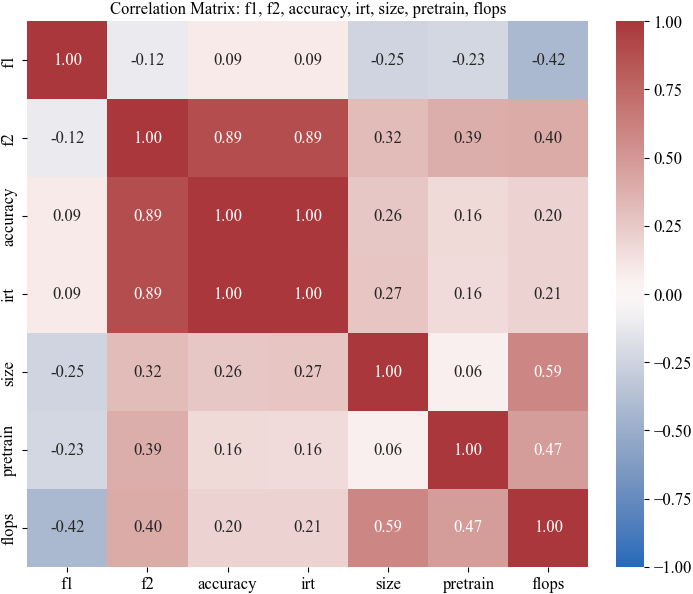

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

# Join model specs
model_score_df = theta_score_df.join(model_spec.set_index("code"), how="left")

# Select relevant columns for correlation
corr_cols = ['f1', 'f2', 'accuracy', 'irt', 'size', 'pretrain', 'flops']
corr_df = model_score_df[corr_cols].copy()

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix: f1, f2, accuracy, irt, size, pretrain, flops")
# Use constrained_layout to avoid RuntimeError with colorbar and tight_layout
fig.set_constrained_layout(True)
plt.show()